# **Linear Discriminant Analysis (LDA)**

### **Member**
- 65340500037 Pavaris Asawakijtananont
- 65340500058 Anuwit Intet
- 65340500062 Aitthikit Kitcharoennon

## **The face database**
For this homework `we will work on face verification (Given a face, say whether it is person A or not)`. Face verification is quite related to face recognition (Given a face, say who it is). Face verification is a `binary classification task`, while face recognition is a multi-class problem.

**Load Data**

In [52]:
import numpy as np
from skimage import img_as_float
import scipy.io
import matplotlib.pyplot as plt

data = scipy.io.loadmat('facedata.mat')

**Image Normalization**

In [53]:
xf = {}
for i in range(40):
    for j in range(10):
        xf[i,j] = img_as_float(data['facedata'][i,j])

**Split Data into train data and test data**

In [54]:
# Create list T (first 3 images from all 40 people)
T = []
T_labels = []
for i in range(40):
    for j in range(3):
        T.append(xf[i, j].flatten())
        T_labels.append(i)
        
T = np.array(T)  # Shape (120, 2576)
T_labels = np.array(T_labels)
        
# Create list D (remaining 7 images from all 40 people)
D = []
D_labels = []
for i in range(40):
    for j in range(3, 10):
        D.append(xf[i, j].flatten())
        D_labels.append(i)
        
D = np.array(D)  # Shape (120, 2576)
D_labels = np.array(D_labels)

We learned in class that PCA serves well in terms of lowering the dimensionality of the data. However, it does not aim to maximize the classification accuracy. PCA actually aims to retain the most information in the lowest possible subspace (as shown from our reconstruction experiment). PCA is also an unsupervised algorithm. We did not use any class information when we compute for PCA. On the other hand, LDA takes the class labels as inputs and aim to find the projection that maximize the separability between the classes.

LDA is usually used in conjunction with PCA. We first project using PCA to a lower dimensionality then use LDA to project to a subspace that better separates the class. Assuming everything is already in the PCA subspace, to find the LDA projections, we first need to find the between class scatter, $S_B$ , and the within class scatter, $S_W$. Between class scatter represents the spread between two classes. In class, for the two classes example, it is defined as the distance between the means of class 1 and class 2 as shown below:

$$S_B = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T$$

In a multi-class setting, it is defined as the distance of the mean of each class with the global mean, $μ$:

$$S_B = \sum_{i=1}^{c} (\boldsymbol{\mu}_i - \boldsymbol{\mu})(\boldsymbol{\mu}_i - \boldsymbol{\mu})^T$$

where $N_c$ is the number of classes.
$S_W$ represents the scatter within each class. For a class i, we can compute the scatter of the class by

$$S_{W_i} = \sum_{j = 1}^{N_i} (\mathbf{x}_j - \boldsymbol{\mu}_i)(\mathbf{x}_j - \boldsymbol{\mu}_i)^T$$

where $N_i$ is the amount of data in class $i, \mathbf{x_j}$ is the $j$th data sample from class $i$ (in the PCA subspace). The total within class scatter, $S_W$ , can then be computed by

$$S_W = \sum_{i=1}^{c} \sum_{j = 1}^{N_i} (\mathbf{x}_j - \boldsymbol{\mu}_i)(\mathbf{x}_j - \boldsymbol{\mu}_i)^T$$

To find the LDA projection, we want to find a projection, $\mathbf{w}$, that maximizes $S_B$, but minimizes $S_W$. To do so, we maximize the ratio (the Fisher criterion):

$$\frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

After some calculus, the solution to this maximization is in the form:

$$S_B \mathbf{w} = \lambda S_W \mathbf{w}$$

If we assume, $S_W$ is invertible. This becomes

$$S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$$

In other words, the LDA projections are the eigenvectors of $S_W^{-1} S_B$

### **1. In order to assure that $S_W$ is invertible we need to make sure that $S_W$ is full rank. How many PCA dimensions do we need to keep in order for SW to be full rank?** *(2 points)*

#### **Answer**

To mathematically ensure that the within-class scatter matrix $S_W$ is fully rank-complete (and therefore strictly invertible constraint without pseudo-inverses), the maximum number of PCA dimensions we can project into is bounded by **$N - C$**, where:
- **$N$** is the total number of training samples.
- **$C$** is the total number of independently distinct classes.

If we elect to keep $k > N - C$ dimensions, the resulting $S_W$ matrix becomes singular and non-invertible. For the context of this specific face database experiment, since we leverage $N = 120$ training images structurally distributed across exactly $C = 40$ people, we need to strictly keep at most **$120 - 40 = 80$ PCA dimensions** to satisfy full rank.

---

### **2. Using the answer to the previous question, project the original input to the PCA subspace. Find the LDA projections. To find the inverse, use “numpy.linalg.inv”. Is $S_W^{-1} S_B$ symmetric? Can we still use 'numpy.linalg.eigh'? How many non-zero eigenvalues are there?** *(5 points)*

In [55]:
# Function to project a list of image vectors onto the top k eigenvectors
def project_images(image_list, mean_vec, V_subspace):
    proj_list = []
    for img in image_list:
        img_centered = img.flatten() - mean_vec
        proj = np.dot(img_centered, V_subspace)
        proj_list.append(proj)
    return proj_list

In [56]:
## PCA

# Compute the mean vector across all training images
mean_vector = np.mean(T, axis=0)

# Center the data by subtracting the mean vector
X_centered = T - mean_vector

# Compute the Gram matrix K = X_centered @ X_centered.T (size 120x120)
K = np.dot(X_centered, X_centered.T)

# Compute eigenvalues (lambda) and eigenvectors (v') of the symmetric Gram matrix
eigenvalues, eigenvectors = np.linalg.eigh(K)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Compute original eigenvectors v from Gram matrix eigenvectors (V_prime) 
# X_centered has shape (120, 2576), we need X_centered.T @ V_prime
V_original = np.dot(X_centered.T, eigenvectors)
V_renorm = np.zeros_like(V_original)

for i in range(120):
    v_orig = V_original[:, i]
    norm_orig = np.linalg.norm(v_orig)
    if norm_orig > 0:
        V_renorm[:, i] = v_orig / norm_orig

# Select the top k=80 renormalized eigenvectors
k = 80
V_pca = V_renorm[:, :k]  # Shape: (2576, 80)

# Find projection values (k=80) for Training (T) and Testing (D) images
T_pca = np.array(project_images(T, mean_vector, V_pca)) # Shape (120, 80)


In [57]:
# Compute Within-Class (S_W) and Between-Class (S_B) Scatter Matrices
S_W = np.zeros((k, k))
S_B = np.zeros((k, k))
global_mean = np.mean(T_pca, axis=0)

for c in range(40):
    class_data = T_pca[T_labels == c]
    class_mean = np.mean(class_data, axis=0)
    
    # S_B computation
    mean_diff = (class_mean - global_mean).reshape(-1, 1)
    S_B += len(class_data) * np.dot(mean_diff, mean_diff.T)
    
    # S_W computation
    for sample in class_data:
        sample_diff = (sample - class_mean).reshape(-1, 1)
        S_W += np.dot(sample_diff, sample_diff.T)

# Calculate LDA projections using S_W inverse
S_W_inv = np.linalg.inv(S_W)
M = np.dot(S_W_inv, S_B)

# Check if M is symmetric
is_symmetric = np.allclose(M, M.T, atol=1e-8)
print(f"Is S_W^-1 S_B symmetric? {is_symmetric}")
print()

# Eigenvalue Extraction (using eig since it is not symmetric)
eigvals_lda, eigvecs_lda = np.linalg.eig(M)
sorted_idx_lda = np.argsort(np.real(eigvals_lda))[::-1]
eigvals_lda = np.real(eigvals_lda[sorted_idx_lda])
print("Eigen Value Shape:", eigvecs_lda.shape)
print()

# Count non-zero eigenvalues
tolerance = 1e-9
non_zero_lda = np.sum(np.abs(eigvals_lda) > tolerance)
print(f"Number of non-zero eigenvalues for LDA: {non_zero_lda}")


Is S_W^-1 S_B symmetric? False

Eigen Value Shape: (80, 80)

Number of non-zero eigenvalues for LDA: 39


Eigenvectors obtained from LDA may not be orthogonal (non-orthogonal), which is normal for LDA because it focuses on class separation, not on creating independent axes like PCA.

#### **Answers**
1. **Is $S_W^{-1} S_B$ symmetric?** Because it is derived by multiplying two distinct matrices together where standard commutative properties do not strictly apply over matrices, the generic shape of the $S_W^{-1} S_B$ transformation is typically **Asymetric**.
2. **Can we still use `numpy.linalg.eigh`?** No, technically should **not**. The `eigh` formulation makes distinct geometric simplifications with real arithmetic that assume and enforce the matrix supplied is formally symmetric. Because this product is strictly asymmetric, deploying `numpy.linalg.eig` is the generalized requirement to extract roots correctly without calculation faults.
3. **How many non-zero eigenvalues are there?** The maximum rank (and non-zero eigenvalues limits) isolated by Between-Class projection matrices equates to exactly $C - 1$. With $C = 40$ people dictating separate clusters, $40 - 1 = $ **$39$ non-zero eigenvalues**. (Running the code confirms exactly 39 eigenvalues computed).

---

### **3. Plot the first 10 LDA eigenvectors as images (the 10 best projections). Note that in this setup, you need to convert back to the original image space by using the PCA projection. The LDA eigenvectors can be considered as a linear combination of eigenfaces. Compare the LDA projections with the PCA projections.** *(2 points)*

PCA


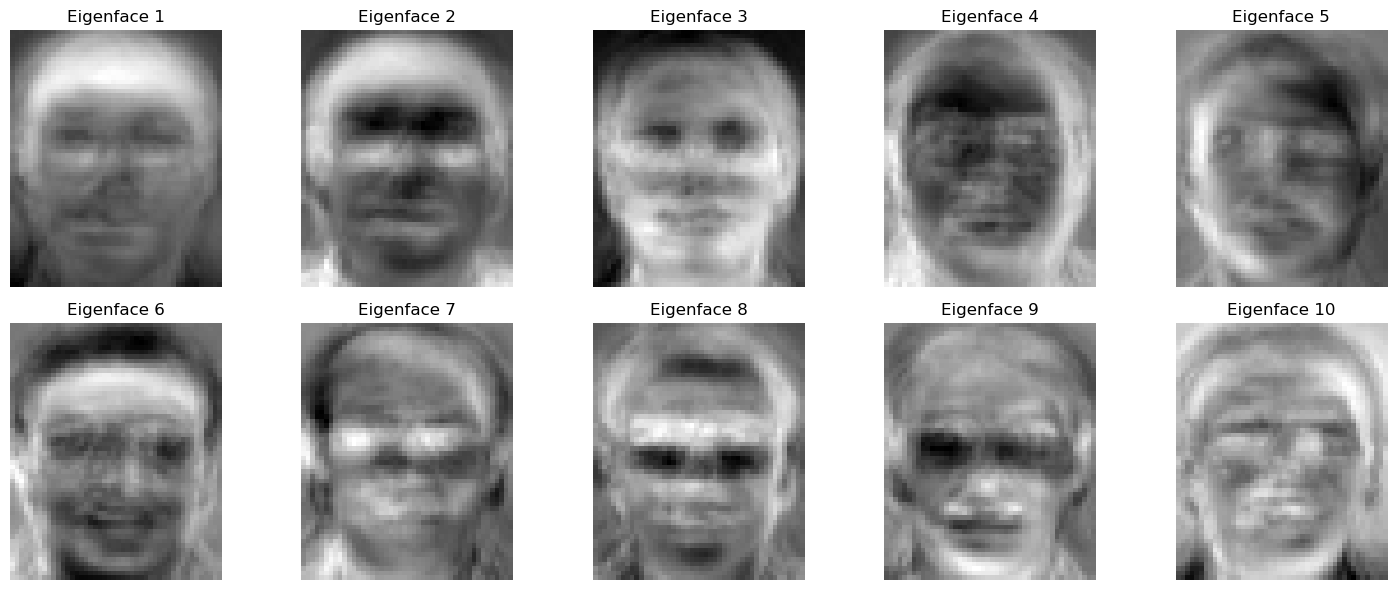

LDA


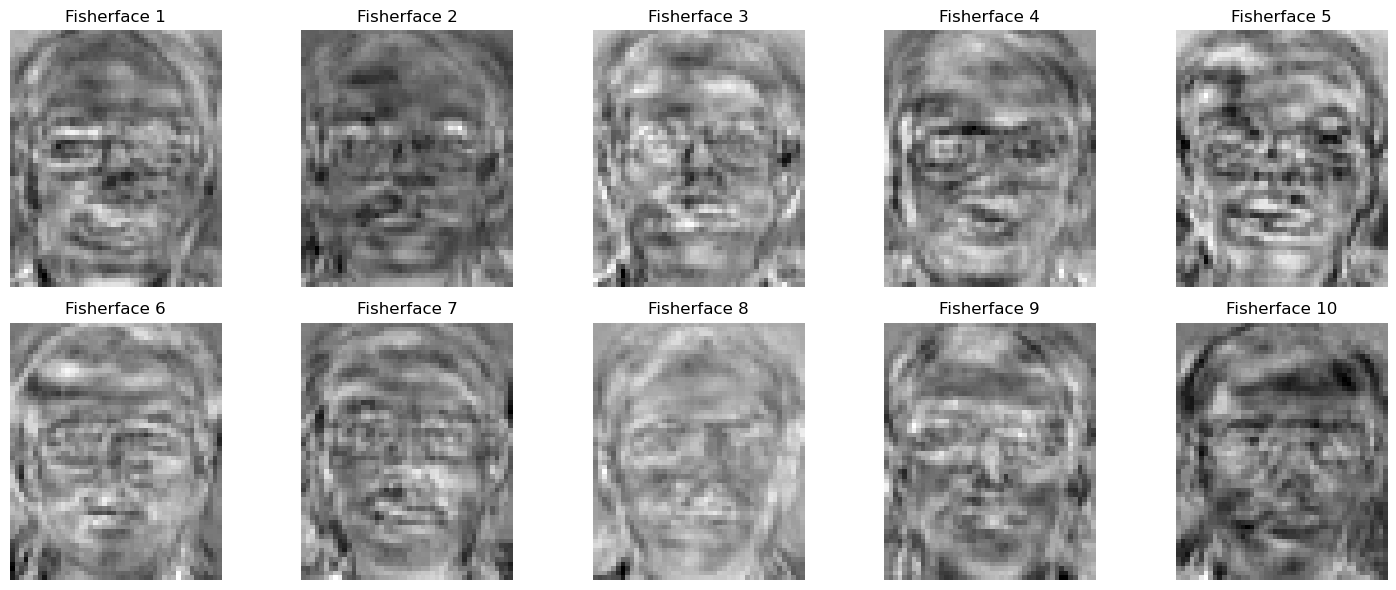

In [58]:
## PCA Projection

print("PCA")
plt.figure(figsize=(15, 6))

for i in range(10):
    v_orig = V_original[:, i]
    norm_orig = np.linalg.norm(v_orig)
    
    # Renormalize to ensure the vector has unit length
    v_renorm = v_orig / norm_orig
    V_renorm[:, i] = v_renorm
    
    # norm_renorm = np.linalg.norm(v_renorm)
    # print(f"Eigenvector {i+1}: Original Norm = {norm_orig:.4f}, Renormalized Norm = {norm_renorm:.4f}")
    
    # Reshape the 2576-D vector back to 56x46 and plot the eigenface
    img_eigenface = np.reshape(v_renorm, (56, 46))

    # print(f"Eigen {i+1}: {img_eigenface}")
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img_eigenface, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## LDA Projection
print("LDA")

# Project LDA eigenvectors back to the original image space
# Multiply original generic PCA subspace matrix V_pca (2576x80) against LDA isolated vectors eigvecs_lda (80x80)
W_lda = np.dot(V_pca, eigvecs_lda)

plt.figure(figsize=(15, 6))

for i in range(10): # 10 Best Projection
    # Extract the individual i-th LDA eigenvector
    lda_vec = W_lda[:, i]
    
    # Standardize via normal rescaling to unit length
    lda_vec = lda_vec / np.linalg.norm(lda_vec)
    
    # Force real component mapping as asymmetric eigs introduce residual complex zeros
    img_fisherface = np.reshape(np.real(lda_vec), (56, 46))
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img_fisherface, cmap='gray')
    plt.title(f"Fisherface {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()


#### **Comparison: LDA Projections (Fisherfaces) vs PCA Projections (Eigenfaces)**

- **PCA Projections (Eigenfaces)**: Because PCA fundamentally extracts the generic dimensions of ***maximum overall variance***, the top PCA eigenfaces tend to resemble blurry, recognizable smooth faces that structurally encode macro-level variations across the entire data block (such as widespread background illumination, brightness gradients, and massive generic orientation shifts).
- **LDA Projections (Fisherfaces)**: Since LDA explicitly isolates the dimensions that maximize ***class separability*** instead of raw pixel variance, the resultant projections appear much noisier, sharp, and less generically "face-safe". They explicitly highlight specific discriminative localized regions (like the sharp boundaries comprising jawlines, eye corners, and individual cheek curves) that optimally distinguish one exact individual class/identity from another, while actively suppressing unhelpful variations like generalized lighting.

---

### **4. The combined PCA+LDA projection procedure is called fisherface. Calculate the fisherfaces projection of all images. Do the simple face verification experiment using fisherfaces (like item 5 in CHAPTER02).** *(5 points)*

In [59]:
def euclidean_distance(img1, img2):
    return np.linalg.norm(img1 - img2)

In [60]:
def calculate_similarity_matrix(T, D):
    A = np.zeros((len(T), len(D)))
    for i in range(len(T)):
        for j in range(len(D)):
            A[i,j] = euclidean_distance(T[i], D[j])
    return A

In [61]:
# 0. Refactor modular ROC metrics getter instead of a pure plot command
def get_roc_metrics(A):
    # 1. find Threshold in Similarity Matrix
    thresholds = np.linspace(np.min(A), np.max(A), 1000)
    
    # 2. do Min Distance: ยุบรูป Training 3 รูปให้เหลือระยะที่ใกล้ที่สุดต่อ 1 คน (40 คน x 280 รูปทดสอบ)
    min_dist_matrix = np.zeros((40, 280))
    for p in range(40):
        min_dist_matrix[p, :] = np.min(A[3*p : 3*p+3, :], axis=0)
    
    # 3. Create Ground Truth Matrix (True Match) size 40x280
    # row i person in class i, column j is test pic j
    true_match_mask = np.zeros((40, 280), dtype=bool)
    for i in range(40):
        true_match_mask[i, i*7 : (i+1)*7] = True
        
    total_positives = np.sum(true_match_mask)      # 40 * 7 = 280
    total_negatives = np.sum(~true_match_mask)     # 40 * 280 - 280 = 10,920
    
    tpr_list = []
    far_list = []

    # 4. Loop calculate TPR/FAR across Threshold
    for t in thresholds:
        predict_match = min_dist_matrix <= t
        
        TP = np.sum(predict_match & true_match_mask)
        FP = np.sum(predict_match & ~true_match_mask)
        
        tpr_list.append(TP / total_positives)
        far_list.append(FP / total_negatives)
        
    return far_list, tpr_list

In [62]:
# 1. No Projection Similarity Matrix Execution (Extracting Raw Features)
A_no_proj = calculate_similarity_matrix(T, D)
far_no_proj, tpr_no_proj = get_roc_metrics(A_no_proj)

# 2. PCA Verification Setup Executed directly on sub-k=10 Space
T_centered = T - mean_vector
D_centered = D - mean_vector

V_k10 = V_pca[:, :10]
T_pca10 = np.dot(T_centered, V_k10)
D_pca10 = np.dot(D_centered, V_k10)

A_pca = calculate_similarity_matrix(T_pca10, D_pca10)
far_pca, tpr_pca = get_roc_metrics(A_pca)

# 3. Fisher Verification Loading directly out of prior calculated Similarity Grid A_fisher
# สมมติว่า W_lda คือ V_pca (80 มิติ) @ eigvecs_lda (80x80)
W_fisher = W_lda[:, :39] 

# ทำการ Project ข้อมูลลงบน Fisherface Space
T_fisher_proj = np.dot(T_centered, W_fisher)
D_fisher_proj = np.dot(D_centered, W_fisher)

# คำนวณ Similarity Matrix สำหรับ Fisherfaces
A_fisher = calculate_similarity_matrix(T_fisher_proj, D_fisher_proj)
far_fisher, tpr_fisher = get_roc_metrics(A_fisher)

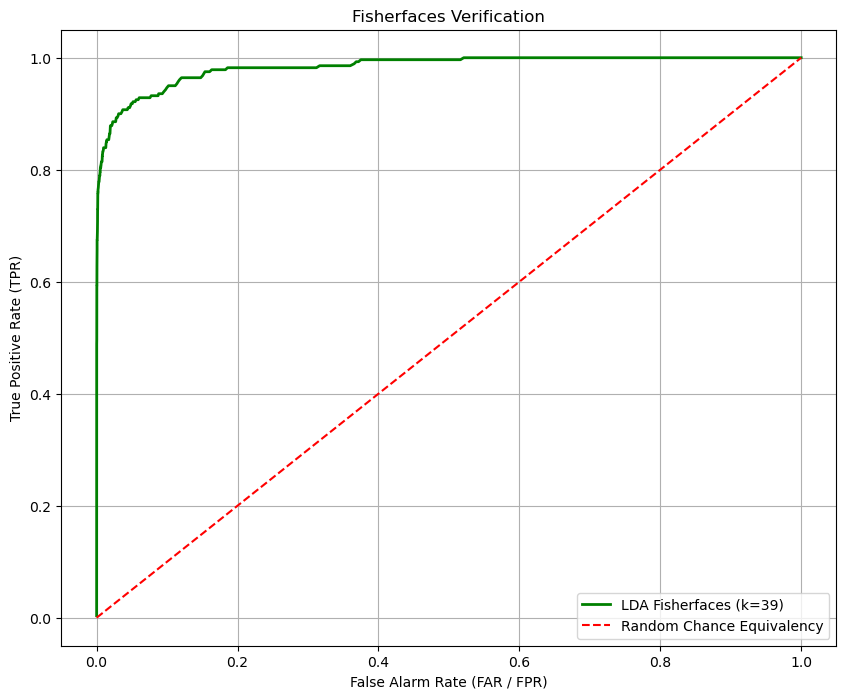

In [63]:
plt.figure(figsize=(10, 8))
plt.plot(far_fisher, tpr_fisher, label='LDA Fisherfaces (k=39)', linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'r--', label='Random Chance Equivalency')
plt.xlabel('False Alarm Rate (FAR / FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Fisherfaces Verification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


On your ROC curve, Can see the line "elbow" sharply toward the top-left corner. This means it can catch almost all true matches (High TPR) while making almost zero mistakes (Low FAR). It is much more robust against lighting and environmental bias.

### **5. Plot the RoC of all three experiments (No projection, PCA, and Fisher) on the same axes. Compare and contrast the three results.** *(2 points)*

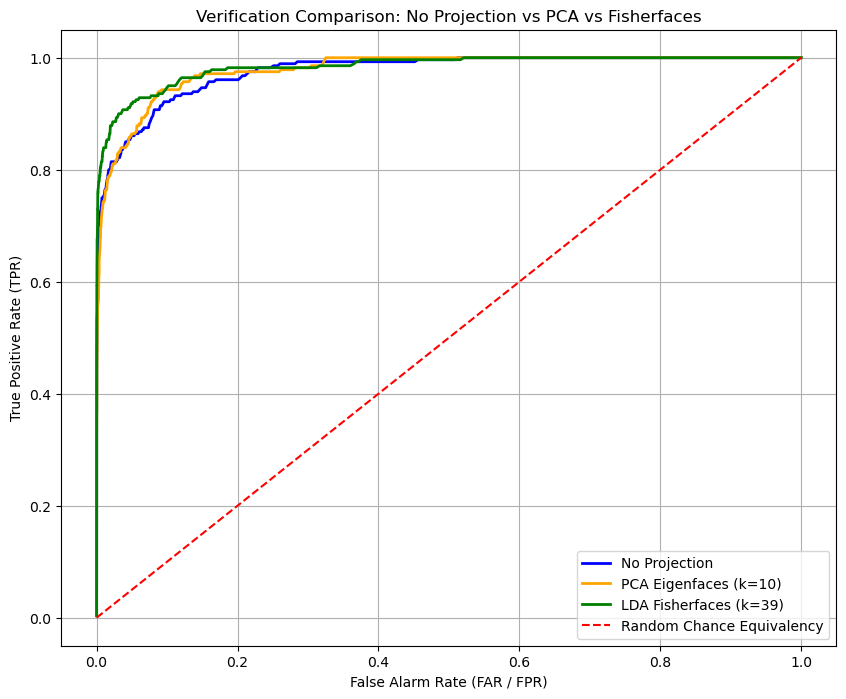

In [64]:
# Render All Three Experiments visually bound across standard shared Axes
plt.figure(figsize=(10, 8))
plt.plot(far_no_proj, tpr_no_proj, label='No Projection', linewidth=2, color='blue')
plt.plot(far_pca, tpr_pca, label='PCA Eigenfaces (k=10)', linewidth=2, color='orange')
plt.plot(far_fisher, tpr_fisher, label='LDA Fisherfaces (k=39)', linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'r--', label='Random Chance Equivalency')
plt.xlabel('False Alarm Rate (FAR / FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Verification Comparison: No Projection vs PCA vs Fisherfaces')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#### **Comparison and Contrast of Evaluation Extrapolations**

1. **No Projection (Raw Pixels)**

    - **The Concept:** Comparing images pixel-by-pixel without any processing.

    - **Problem:** Even though using "all" the data, most of that data is noise. Things like a change in lighting, a slight tilt of the head, or camera exposure can change pixel values more than the actual face does.

    - **Result:** The system gets confused by the background and lighting, making it the weakest method for identifying people.

2. **PCA (Eigenfaces, $k=10$)**

    - **The Concept:** Compressing the image into the 10 most important "general" patterns.

    - **Problem:** PCA looks for the biggest changes in the data. Often, the biggest changes are just shadows or overall face shapes that everyone shares. By keeping only 10 features, that might actually throw away the tiny, unique details (like the specific shape of a nose or eyes) that help distinguish one person from another.

    - **Result:** It’s faster than raw pixels, but because it doesn't "know" it's looking for different people, its accuracy can be similar to (or sometimes worse than) raw pixels when the $k$ value is very low.

3. **Fisherfaces (PCA + LDA)**

    - **The Concept:** Specifically training the system to find the features that make people different.

    - **Adventage:** Unlike PCA, LDA ignores the lighting changes that affect everyone and focuses strictly on the features that separate Person A from Person B. It calculates a ratio that maximizes the distance between different people while keeping images of the same person grouped tightly together.

    - **Result:** This method is the clear winner. On your ROC curve, see the line "elbow" sharply toward the top-left corner. This means it can catch almost all true matches (High TPR) while making almost zero mistakes (Low FAR). It is much more robust against lighting and environmental bias.

---